<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Decision Tree on Iris Dataset</b>
</h1>

<div style="font-family:'Times New Roman';">

<b>Goal:</b>

<ol>
<li>Train a Decision Tree on a multi-class dataset.</li>
<li>Understand how trees handle more than two classes.</li>
<li>Visualize the learned tree.</li>
<li>Analyze feature importance.</li>
</ol>

In this notebook, I'll use the famous Iris dataset to see how a Decision Tree separates different flower species using simple rules.

</div>

In [ ]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

In [2]:
# load dataset

iris = load_iris()

X = iris.data
y = iris.target

In [3]:
# basic information

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nClasses :", iris.target_names)

Features Shape : (150, 4)
Target Shape : (150,)

Classes : ['setosa' 'versicolor' 'virginica']


In [4]:
# create dataframe

df = pd.DataFrame(X, columns=iris.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
# class distribution

pd.Series(y).value_counts()

0    50
1    50
2    50
Name: count, dtype: int64

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Dataset Overview</b>
</h2>

<div style="font-family:'Times New Roman';">

The Iris dataset contains measurements of flowers from three different species.

<ul>
<li><b>0:</b> Setosa</li>
<li><b>1:</b> Versicolor</li>
<li><b>2:</b> Virginica</li>
</ul>

The goal is to correctly identify the flower species based on its measurements.

</div>

In [7]:
# split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
# train decision tree

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
# predictions

y_pred = tree.predict(X_test)

In [10]:
# accuracy

acc = accuracy_score(y_test, y_pred)

print("Accuracy :", round(acc,4))

Accuracy : 1.0


In [11]:
# confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [12]:
# classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Model Performance</b>
</h2>

<div style="font-family:'Times New Roman';">

The model achieved <b>100% accuracy</b> on the test set.

<ul>
<li><b>Setosa:</b> Precision = 1.00, Recall = 1.00</li>
<li><b>Versicolor:</b> Precision = 1.00, Recall = 1.00</li>
<li><b>Virginica:</b> Precision = 1.00, Recall = 1.00</li>
</ul>

This means every flower in the test set was classified correctly.

The Iris dataset is relatively small and the classes are well seperated, which makes it easier for a Decision Tree to find clear decision boundaries.

</div>

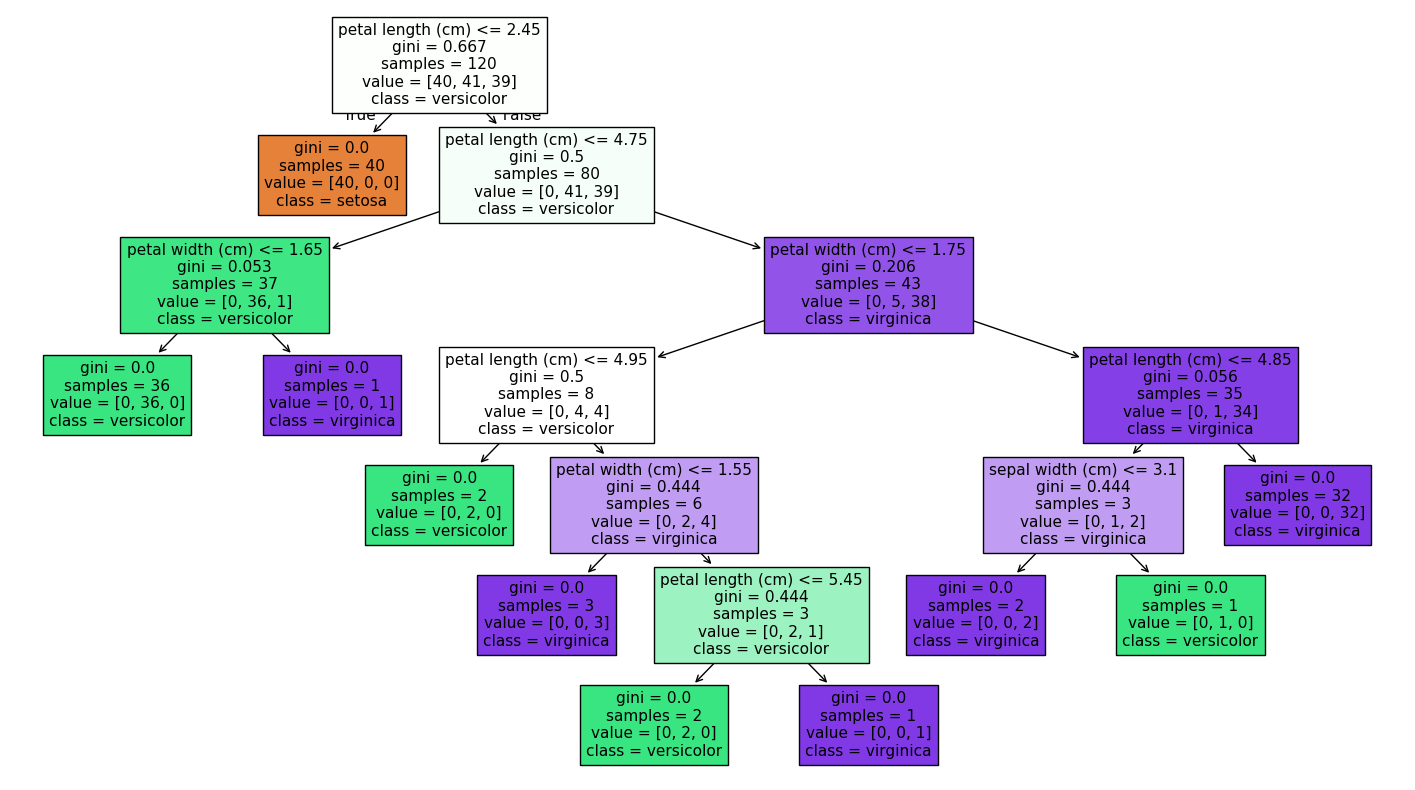

In [13]:
# visualize tree

plt.figure(figsize=(18,10))

plot_tree(
    tree,
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names
)

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Tree Visualization</b>
</h2>

<div style="font-family:'Times New Roman';">

Each node represents a decision rule.

The tree keeps splitting the data until it can confidently classify the flower species.

</div>

In [14]:
# feature importance

importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": tree.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
2,petal length (cm),0.906143
3,petal width (cm),0.077186
1,sepal width (cm),0.016670
0,sepal length (cm),0.000000


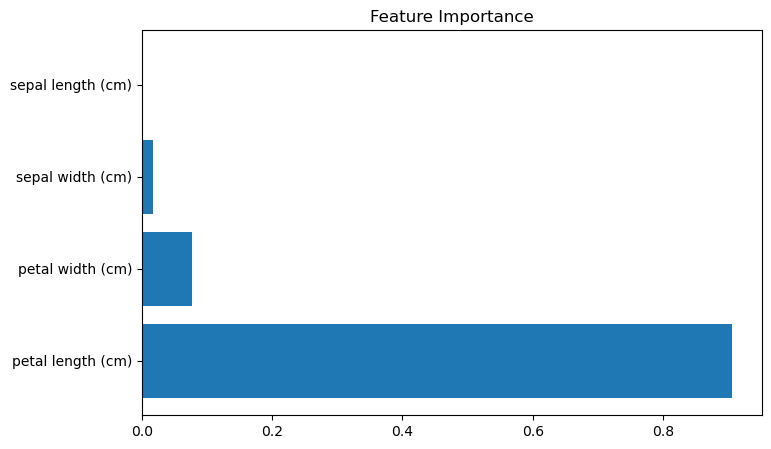

In [15]:
# plotting feature importance

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Feature Importance</b>
</h2>

<div style="font-family:'Times New Roman';">

Some features contribute more than others while making decisions.

Features with higher importance have a bigger influence on the final prediction.

</div>

In [16]:
train_acc = tree.score(X_train, y_train)

print("Train Accuracy :", round(train_acc,4))
print("Test Accuracy  :", round(acc,4))

Train Accuracy : 1.0
Test Accuracy  : 1.0


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Overfitting Check</b>
</h2>

<div style="font-family:'Times New Roman';">

<ul>
<li><b>Train Accuracy:</b> 100%</li>
<li><b>Test Accuracy:</b> 100%</li>
</ul>

The model performed perfectly on both the training and test data.

For this dataset, the classes are naturally well seperated, allowing the tree to learn very clear decision rules.

This does not always happen in real-world datasets where the patterns are usually more complex.

</div>